In [21]:
import os
import logging
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


## LOGGING CONFIGURATION

In [22]:
LOG_DIR = "logs"
os.makedirs(LOG_DIR, exist_ok=True)

LOG_FILE = os.path.join(LOG_DIR, "langgraph_agent.log")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, encoding="utf-8"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger("LangGraphAgent")

## LOAD ENVIRONMENT VARIABLES

In [23]:
try:
    load_dotenv()
    GROQ_API_KEY = os.getenv("GROQ_API_KEY")
    TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY is missing from the .env file.")

    if not TAVILY_API_KEY:
        raise ValueError("TAVILY_API_KEY is missing from the .env file.")

    logger.info("Environment variables loaded successfully.")

except Exception:
    logger.exception("Failed to load environment variables.")
    raise

2026-09-12 17:26:32,929 | INFO | LangGraphAgent | Environment variables loaded successfully.


## CREATE ARXIV TOOL

In [24]:
try:
    arxiv_wrapper = ArxivAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=500
    )

    arxiv = ArxivQueryRun(
        api_wrapper=arxiv_wrapper,
        description = "Search and retrieve information from arXiv research papers."
    )

    logger.info("arxiv tool initialized successfully.")

except Exception:
    logger.exception("Failed to initialize arXiv tool.")
    raise


2026-09-12 17:26:33,386 | INFO | LangGraphAgent | arxiv tool initialized successfully.


## Failed to initialize arXiv tool.

In [25]:
try:

    arxiv_wrapper = ArxivAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=500
    )

    arxiv = ArxivQueryRun(
        api_wrapper=arxiv_wrapper,
        description="Search and retrieve information from arXiv research papers."
    )

    logger.info("arXiv tool initialized successfully.")

except Exception:

    logger.exception(
        "Failed to initialize arXiv tool."
    )

    raise

2026-09-12 17:26:33,875 | INFO | LangGraphAgent | arXiv tool initialized successfully.


## CREATE TAVILY SEARCH TOOL

In [26]:
try:

    tavily = TavilySearch(
        max_results=2
    )

    logger.info(
        "Tavily search tool initialized successfully."
    )

except Exception:

    logger.exception(
        "Failed to initialize Tavily tool."
    )

    raise

2026-09-12 17:26:34,383 | INFO | LangGraphAgent | Tavily search tool initialized successfully.


## COMBINE ALL TOOLS

In [27]:
tools = [
    arxiv,
    wiki,
    tavily
]

logger.info(
    "Tools registered: %s",
    [tool.name for tool in tools]
)

2026-09-12 17:26:36,704 | INFO | LangGraphAgent | Tools registered: ['arxiv', 'wikipedia', 'tavily_search']


## CREATE GROQ LLM

In [36]:
try:
    llm = ChatGroq(
        model="openai/gpt-oss-120b",
        temperature=0
    )

    logger.info("Groq LLM initialized successfully.")

except Exception:
    logger.exception("Failed to bind tools to LLM")
    raise



2026-09-12 17:29:00,445 | INFO | LangGraphAgent | Groq LLM initialized successfully.


## BIND TOOLS TO LLM

In [37]:
try:

    llm_with_tools = llm.bind_tools(tools)

    logger.info("Tools successfully bound to LLM.")

except Exception:

    logger.exception("Failed to bind tools to LLM. ")
    raise

2026-09-12 17:29:03,077 | INFO | LangGraphAgent | Tools successfully bound to LLM.


## DEFINE LANGGRAPH STATE

In [38]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

## LLM NODE

In [39]:
def tool_calling_llm(state: State):

    logger.info("LLM node started.")

    try:

        messages = state["messages"]

        logger.info(
            "Sending %d message(s) to LLM.",
            len(messages)
        )

        response = llm_with_tools.invoke(messages)

        if response.tool_calls:

            logger.info(
                "LLM requested %d tool call(s).",
                len(response.tool_calls)
            )

            for tool_call in response.tool_calls:

                logger.info(
                    "Tool requested: %s | Arguments: %s",
                    tool_call["name"],
                    tool_call["args"]
                )

        else:

            logger.info(
                "LLM returned a direct response without tool calls."
            )

        return {
            "messages": [response]
        }

    except Exception:

        logger.exception(
            "Error occurred while invoking LLM."
        )

        raise

## CREATE LANGGRAPH

In [40]:
try:

    graph_builder = StateGraph(State)

    # Add LLM node

    graph_builder.add_node(
        "tool_calling_llm",
        tool_calling_llm
    )

    # Add ToolNode

    graph_builder.add_node(
        "tools",
        ToolNode(tools)
    )

    # START → LLM

    graph_builder.add_edge(
        START,
        "tool_calling_llm"
    )

    # LLM → Tool OR END
    
    graph_builder.add_conditional_edges(
        "tool_calling_llm",
        tools_condition
    )

    # Tools → LLM
    # This creates the ReAct loop.

    graph_builder.add_edge(
        "tools",
        "tool_calling_llm"
    )

    # Compile graph

    graph = graph_builder.compile()

    logger.info("LangGraph compiled successfully.")

except Exception:

    logger.exception(
        "Failed to create or compile LangGraph."
    ) 

    raise





2026-09-12 17:29:04,759 | INFO | LangGraphAgent | LangGraph compiled successfully.


## DISPLAY GRAPH

In [41]:
print("\n" + "=" * 70)
print("LANGGRAPH CREATED SUCCESSFULLY")
print("=" * 70)

try:

    print(
        graph.get_graph().draw_ascii()
    )

except Exception:

    logger.warning(
        "ASCII graph visualization is not available."
    )

2026-09-12 17:29:05,067 | WARNING | LangGraphAgent | ASCII graph visualization is not available.



LANGGRAPH CREATED SUCCESSFULLY


## GET USER INPUT

In [43]:
try:

    user_query = input(
        "\n🧠 Ask your question: "
    ).strip()

    if not user_query:

        raise ValueError(
            "Question cannot be empty."
        )

    logger.info(
        "User query received: %s",
        user_query
    )

except Exception:

    logger.exception(
        "Invalid user input."
    )

    raise

2026-09-12 17:29:22,981 | INFO | LangGraphAgent | User query received: hello can i know capital of india


## INVOKE LANGGRAPH

In [44]:
try:

    logger.info("Starting LangGraph execution...")

    response = graph.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_query
                }
            ]
        }
    )

    logger.info("LangGraph execution completed successfully.")

except Exception:

    logger.exception("LangGraph execution failed.")

    print("\n❌ An error occurred while processing your question.")
    print(f"Check the log file: {LOG_FILE}")

    raise

2026-09-12 17:29:27,978 | INFO | LangGraphAgent | Starting LangGraph execution...
2026-09-12 17:29:27,981 | INFO | LangGraphAgent | LLM node started.
2026-09-12 17:29:27,982 | INFO | LangGraphAgent | Sending 1 message(s) to LLM.
2026-09-12 17:29:28,831 | INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-09-12 17:29:28,858 | INFO | LangGraphAgent | LLM returned a direct response without tool calls.
2026-09-12 17:29:28,860 | INFO | LangGraphAgent | LangGraph execution completed successfully.


## DISPLAY CONVERSATION

In [45]:
print("\n" + "=" * 70)
print("CONVERSATION")
print("=" * 70)

try:

    for message in response["messages"]:

        print(
            f"\n[{type(message).__name__}]"
        )

        # ----------------------------------------------------
        # Display tool calls
        # ----------------------------------------------------

        if (
            hasattr(message, "tool_calls")
            and message.tool_calls
        ):

            print("\nTool Calls:")

            for tool_call in message.tool_calls:

                print(
                    f"  Tool   : {tool_call['name']}"
                )

                print(
                    f"  Args   : {tool_call['args']}"
                )

        # ----------------------------------------------------
        # Display message content
        # ----------------------------------------------------

        if (
            hasattr(message, "content")
            and message.content
        ):

            print(
                f"\nContent:\n{message.content}"
            )

except Exception:

    logger.exception(
        "Failed while displaying conversation."
    )



CONVERSATION

[HumanMessage]

Content:
hello can i know capital of india

[AIMessage]

Content:
The capital of India is **New Delhi**.


##  DISPLAY FINAL ANSWER

In [46]:
print("\n" + "=" * 70)
print("FINAL ANSWER")
print("=" * 70)

try:

    final_answer_found = False

    for message in reversed(
        response["messages"]
    ):

        if (
            type(message).__name__ == "AIMessage"
            and message.content
        ):

            print(
                "\n" + message.content
            )

            final_answer_found = True

            logger.info(
                "Final answer displayed successfully."
            )

            break

    if not final_answer_found:

        logger.warning(
            "No final AI answer was found."
        )

        print(
            "\n⚠️ No final answer was generated."
        )

except Exception:

    logger.exception(
        "Failed to display final answer."
    )

    print(
        "\n❌ Unable to display the final answer."
    )

2026-09-12 17:29:44,847 | INFO | LangGraphAgent | Final answer displayed successfully.



FINAL ANSWER

The capital of India is **New Delhi**.


## PROGRAM COMPLETED

In [47]:
logger.info(
    "Program execution completed."
)

print(
    f"\n📝 Logs saved to: {LOG_FILE}"
)

2026-09-12 17:29:49,229 | INFO | LangGraphAgent | Program execution completed.



📝 Logs saved to: logs\langgraph_agent.log


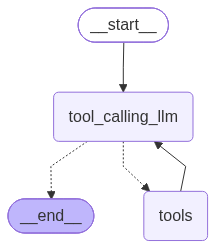

2026-09-12 17:32:20,667 | INFO | LangGraphAgent | LangGraph visualization displayed successfully.


In [48]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
    logger.info("LangGraph visualization displayed successfully.")
except Exception:
    logger.exception("Could not display LangGraph visualization.")